In [ ]:
from collections import deque

import matplotlib.pyplot as plt
import networkx as nx

"""
Projekt: maksymalny przeplyw algorytmem Dinitza

Opis ogolny
Program rozwiazuje problem maksymalnego przeplywu w sieci skierowanej.
Mamy graf z przepustowosciami na krawedziach, jedno zrodlo s i jedno ujscie t.
Chcemy przeslac ze zrodla do ujscia jak najwieksza mozliwa ilosc przeplywu.

Najwazniejsza idea
Algorytm Dinitza nie pracuje bezposrednio tylko na grafie oryginalnym,
ale na grafie residualnym. Oznacza to, ze dla kazdej krawedzi do przodu
tworzona jest tez krawedz przeciwna. Dzieki temu algorytm moze nie tylko
dodawac przeplyw do przodu, ale tez w razie potrzeby cofac czesc wczesniej
puszczonego przeplywu i poprawiac poprzednie decyzje.

Jak dziala algorytm
1. Na poczatku budowany jest graf residualny.
2. BFS(Breadth-First Search(przeszukiwacze wszerz)) wyznacza warstwy wierzcholkow, czyli tworzy graf warstwowy.
   BFS idzie tylko po krawedziach, na ktorych pozostala jeszcze dodatnia
   przepustowosc residualna.
3. DFS(Depth-First Search(przeszukiwanie w głąb)) probuje przeslac przeplyw od zrodla do ujscia tylko po krawedziach,
   ktore prowadza do nastepnej warstwy. W ten sposob znajduje przeplyw blokujacy.
4. Kazde udane przejscie DFS zmniejsza przepustowosc residualna na krawedzi
   do przodu i zwieksza przepustowosc residualna na krawedzi przeciwnej.
5. Gdy w danej fazie nie da sie juz nic wiecej przeslac, algorytm znow
   uruchamia BFS i buduje nowy graf warstwowy.
6. Algorytm konczy sie wtedy, gdy BFS nie potrafi juz dojsc ze zrodla do ujscia.

Co oznacza wynik
- maksymalny przeplyw: najwieksza wartosc, jaka da sie przeslac z s do t
- przeplywy na krawedziach: ile faktycznie poszlo przez kazda oryginalna krawedz
- graf residualny koncowy: pokazuje, gdzie zostal jeszcze zapas i gdzie mozna
  byloby cofnac przeplyw
- minimalny przekroj: podzial wierzcholkow na zbiory S i T, gdzie S to
  wierzcholki nadal osiagalne ze zrodla w grafie residualnym, a T to reszta

Wazna wlasnosc
Dla poprawnie policzonego wyniku zachodzi twierdzenie:
wartosc maksymalnego przeplywu = pojemnosc minimalnego przekroju.

Co pokazuje program
Program nie tylko liczy wynik koncowy, ale tez:
- wypisuje fazy BFS i DFS
- pokazuje, ile przeplywu przeslano kazda sciezka
- rysuje graf wejsciowy
- rysuje graf koncowy z przeplywami
- rysuje graf residualny koncowy, w tym krawedzie przeciwne
"""




#FUNKCJE POMOCNICZE

"""To jest struktura danych opisująca jedną krawędź w grafie residualnym.
Przechowuję koniec krawędzi, krawędź przeciwną i informację,
ile przepustowości jeszcze zostało."""

class Krawedz:  # jedna krawedz w grafie residualnym
    def __init__(self, dokad, odwrotna, pozostalo, poczatkowa, czy_przeciwna):
        self.dokad = dokad  # do jakiego wierzcholka prowadzi krawedz
        self.odwrotna = odwrotna  # gdzie lezy krawedz przeciwna
        self.pozostalo = float(pozostalo)  # ile mozna jeszcze przeslac ta krawedzia
        self.poczatkowa = float(poczatkowa)  # jaka byla poczatkowa przepustowosc
        self.czy_przeciwna = czy_przeciwna  # czy jest to krawedz przeciwna w grafie residualnym


def ladna_liczba(x, eps=1e-12, miejsca=None):  # ladniejszy zapis liczb
    x = float(x)  # zamieniamy na float
    if abs(x - round(x)) <= eps:  # jesli liczba jest prawie calkowita
        return int(round(x))  # zwracamy int zamiast float
    if miejsca is not None:  # jesli chcemy zaokraglac do kilku miejsc
        return round(x, miejsca)  # zaokraglamy
    return x  # w przeciwnym razie zostawiamy liczbe bez zmian



#WLASCIWY ALGORYTM DINITZA



class Dinitz:  # glowna klasa algorytmu
    def __init__(self, liczba_wierzcholkow, eps=1e-12):
        if liczba_wierzcholkow <= 0:  # liczba wierzcholkow musi byc dodatnia
            raise ValueError("Liczba wierzcholkow musi byc dodatnia.")
        if eps <= 0:  # eps tez musi byc dodatni
            raise ValueError("eps musi byc dodatnie.")

        self.n = liczba_wierzcholkow  # liczba wierzcholkow
        self.eps = eps  # mala liczba do porownan float
        self.graf = [[] for _ in range(self.n)]  # lista sasiedztwa grafu residualnego
        self.poziom = [-1] * self.n  # warstwy z BFS
        self.wsk = [0] * self.n  # pomocnicze wskazniki do DFS
        self.oryginalne = []  # lista oryginalnych krawedzi dodanych przez uzytkownika
        self.czy_policzono = False  # czy maksymalny przeplyw zostal juz policzony
        self.fazy = []  # tu bedziemy zapisywac przebieg BFS i DFS

    def _sprawdz_wierzcholek(self, w):  # sprawdza, czy wierzcholek istnieje
        if not (0 <= w < self.n):  # poprawne numery to 0, 1, ..., n-1
            raise IndexError(f"Wierzcholek {w} jest poza zakresem 0..{self.n - 1}.")
    """
      Ta funkcja dodaje krawędź z grafu wejściowego, ale od razu tworzy też krawędź przeciwną,
      więc przygotowuje graf residualny potrzebny algorytmowi.

    """
    def dodaj_krawedz(self, poczatek, koniec, przepustowosc):  # dodaje krawedz do grafu
        self._sprawdz_wierzcholek(poczatek)  # sprawdzamy poczatek
        self._sprawdz_wierzcholek(koniec)  # sprawdzamy koniec

        if poczatek == koniec:  # nie dopuszczamy petli
            raise ValueError("Petle nie sa dopuszczone w tej implementacji.")

        przep = float(przepustowosc)  # zamieniamy przepustowosc na float
        if przep < -self.eps:  # przepustowosc nie moze byc ujemna
            raise ValueError("Przepustowosc nie moze byc ujemna.")
        if abs(przep) <= self.eps:  # bardzo male liczby traktujemy jako zero
            przep = 0.0

        do_przodu = Krawedz(koniec, len(self.graf[koniec]), przep, przep, False)  # zwykla krawedz
        do_tylu = Krawedz(poczatek, len(self.graf[poczatek]), 0.0, 0.0, True)  # krawedz przeciwna

        self.graf[poczatek].append(do_przodu)  # dopisujemy krawedz do przodu
        self.graf[koniec].append(do_tylu)  # dopisujemy krawedz przeciwna

        self.oryginalne.append((poczatek, len(self.graf[poczatek]) - 1))  # zapamietujemy oryginalna krawedz
        self.czy_policzono = False  # po zmianie grafu wynik trzeba liczyc od nowa

    def _wyzeruj_przeplywy(self):  # przywraca stan poczatkowy
        for poczatek, indeks in self.oryginalne:  # przechodzimy po wszystkich oryginalnych krawedziach
            krawedz = self.graf[poczatek][indeks]  # bierzemy dana krawedz
            odwrotna = self.graf[krawedz.dokad][krawedz.odwrotna]  # znajdujemy krawedz przeciwna
            krawedz.pozostalo = krawedz.poczatkowa  # przywracamy poczatkowa przepustowosc
            odwrotna.pozostalo = 0.0  # krawedz przeciwna znow ma 0

        self.czy_policzono = False  # po resecie uznajemy, ze wynik nie jest policzony
        self.fazy = []  # czyscimy stary przebieg algorytmu
        """
        BFS buduje warstwy w grafie residualnym. Dzięki temu wiem, które wierzchołki
        są na kolejnych poziomach i DFS może iść tylko do przodu po warstwach.
        """
    def _bfs_warstwy(self, zrodlo, ujscie):  # BFS buduje graf warstwowy
        self.poziom = [-1] * self.n  # na poczatku nikt nie ma warstwy
        kolejka = deque([zrodlo])  # kolejka startuje od zrodla
        self.poziom[zrodlo] = 0  # zrodlo ma warstwe 0

        while kolejka:  # dopoki kolejka nie jest pusta
            u = kolejka.popleft()  # bierzemy pierwszy wierzcholek z kolejki
            for krawedz in self.graf[u]:  # przegladamy wszystkie krawedzie z u
                if krawedz.pozostalo > self.eps and self.poziom[krawedz.dokad] == -1:
                    self.poziom[krawedz.dokad] = self.poziom[u] + 1  # nowy wierzcholek dostaje kolejna warstwe
                    kolejka.append(krawedz.dokad)  # dodajemy go do kolejki

        return self.poziom[ujscie] != -1  # True, jesli doszlismy do ujscia
        """
        DFS szuka ścieżki powiększającej w grafie warstwowym i przesyła nią tyle przepływu,
        ile się da. Przy okazji aktualizuje krawędzie zwykłe i przeciwne.
        """
    def _dfs_blokujacy(self, u, ujscie, ile_moge, sciezka):  # DFS szuka przeplywu blokujacego
        if ile_moge <= self.eps:  # jesli nie da sie juz nic przeslac
            return 0.0, None  # zwracamy 0 i brak sciezki

        if u == ujscie:  # jesli doszlismy do ujscia
            return ile_moge, sciezka  # zwracamy ile przeplywu i pelna sciezke krawedzi

        while self.wsk[u] < len(self.graf[u]):  # dopoki sa jeszcze krawedzie do sprawdzenia
            krawedz = self.graf[u][self.wsk[u]]  # bierzemy kolejna krawedz

            if (
                krawedz.pozostalo > self.eps  # krawedzia da sie jeszcze isc
                and self.poziom[krawedz.dokad] == self.poziom[u] + 1  # idziemy tylko do nastepnej warstwy
            ):
                przeslano, znaleziona_sciezka = self._dfs_blokujacy(
                    krawedz.dokad,  # przechodzimy do kolejnego wierzcholka
                    ujscie,  # ujscie sie nie zmienia
                    min(ile_moge, krawedz.pozostalo),  # ogranicza nas najwezsza krawedz
                    sciezka + [(u, krawedz.dokad, krawedz.czy_przeciwna)],  # dopisujemy jedna krawedz do sciezki
                )
                if przeslano > self.eps:  # jesli udalo sie cos przeslac
                    krawedz.pozostalo -= przeslano  # zmniejszamy przepustowosc do przodu
                    self.graf[krawedz.dokad][krawedz.odwrotna].pozostalo += przeslano  # zwiekszamy do tylu
                    return przeslano, znaleziona_sciezka  # zwracamy wartosc i sciezke

            self.wsk[u] += 1  # jesli ta krawedz nie zadzialala, przechodzimy dalej

        return 0.0, None  # jesli nic nie znalezlismy
        """
        To jest główna funkcja algorytmu. Naprzemiennie uruchamia BFS i DFS, aż nie da się już dojść ze źródła do ujścia.
        """
    def maksymalny_przeplyw(self, zrodlo, ujscie):  # glowna funkcja algorytmu
        self._sprawdz_wierzcholek(zrodlo)  # sprawdzamy zrodlo
        self._sprawdz_wierzcholek(ujscie)  # sprawdzamy ujscie

        if zrodlo == ujscie:  # zrodlo i ujscie nie moga byc takie same
            raise ValueError("Zrodlo i ujscie musza byc rozne.")

        self._wyzeruj_przeplywy()  # wracamy do stanu poczatkowego
        wynik = 0.0  # tu bedziemy sumowac przeplyw

        while self._bfs_warstwy(zrodlo, ujscie):  # dopoki BFS dochodzi do ujscia
            faza = {  # zapisujemy jedna faze algorytmu
                "warstwy": list(self.poziom),  # kopia warstw z BFS
                "dfs": [],  # tutaj beda wszystkie udane przepchniecia DFS
                "suma_fazy": 0.0,  # ile lacznie przeslano w tej fazie
            }

            self.wsk = [0] * self.n  # zerujemy wskazniki do DFS

            while True:  # wiele razy uruchamiamy DFS po jednym BFS
                przeslano, sciezka = self._dfs_blokujacy(zrodlo, ujscie, float("inf"), [])  # probujemy pchnac tyle, ile sie da
                if przeslano <= self.eps:  # jesli juz nic sie nie da pchnac
                    break  # konczymy te faze DFS

                wynik += przeslano  # dodajemy przeslana wartosc do wyniku
                faza["dfs"].append(  # zapisujemy udana probe DFS
                    {
                        "sciezka": sciezka,  # po jakich krawedziach poszedl przeplyw
                        "przeslano": przeslano,  # ile udalo sie przeslac
                    }
                )
                faza["suma_fazy"] += przeslano  # zwiekszamy sume przeslana w tej fazie

            self.fazy.append(faza)  # zapamietujemy cala faze

        self.czy_policzono = True  # zapamietujemy, ze wynik juz jest policzony
        return ladna_liczba(wynik, self.eps)  # zwracamy wynik

    def _dane_oryginalnych_krawedzi(self, ladnie=False):  # zbiera dane o oryginalnych krawedziach
        wynik = []  # tu skladamy wynik

        for poczatek, indeks in self.oryginalne:  # przechodzimy po wszystkich oryginalnych krawedziach
            krawedz = self.graf[poczatek][indeks]  # bierzemy dana krawedz
            przeplyw = krawedz.poczatkowa - krawedz.pozostalo  # liczymy, ile nia poszlo

            dane = {
                "od": poczatek,  # skad wychodzi krawedz
                "do": krawedz.dokad,  # dokad prowadzi krawedz
                "przepustowosc": krawedz.poczatkowa,  # poczatkowa przepustowosc
                "przeplyw": przeplyw,  # aktualny przeplyw
                "pozostalo": krawedz.pozostalo,  # ile jeszcze zostalo
            }

            if ladnie:  # jesli chcemy ladniejszy zapis
                dane = {
                    "od": dane["od"],
                    "do": dane["do"],
                    "przepustowosc": ladna_liczba(dane["przepustowosc"], self.eps),
                    "przeplyw": ladna_liczba(dane["przeplyw"], self.eps),
                    "pozostalo": ladna_liczba(dane["pozostalo"], self.eps),
                }

            wynik.append(dane)  # dopisujemy dane tej krawedzi

        return wynik  # zwracamy cala liste

    def przeplywy_na_krawedziach(self):  # zwraca przeplywy na krawedziach
        return self._dane_oryginalnych_krawedzi(ladnie=True)  # wersja ladna do wypisywania

    def krawedzie_grafu_residualnego(self, ladnie=False):  # zwraca dodatnie krawedzie grafu residualnego
        wynik = []  # tu skladamy wynik

        for poczatek in range(self.n):  # przechodzimy po wszystkich wierzcholkach
            for krawedz in self.graf[poczatek]:  # przechodzimy po wszystkich krawedziach wychodzacych
                if krawedz.pozostalo <= self.eps:  # pomijamy krawedzie, po ktorych nie da sie juz isc
                    continue  # przechodzimy do nastepnej krawedzi

                dane = {
                    "od": poczatek,  # skad wychodzi krawedz
                    "do": krawedz.dokad,  # dokad prowadzi krawedz
                    "pozostalo": krawedz.pozostalo,  # ile mozna jeszcze nia przeslac
                    "czy_przeciwna": krawedz.czy_przeciwna,  # czy jest to krawedz przeciwna
                }

                if ladnie:  # jesli chcemy ladniejszy zapis
                    dane = {
                        "od": dane["od"],
                        "do": dane["do"],
                        "pozostalo": ladna_liczba(dane["pozostalo"], self.eps),
                        "czy_przeciwna": dane["czy_przeciwna"],
                    }

                wynik.append(dane)  # dopisujemy jedna krawedz residualna

        return wynik  # zwracamy cala liste dodatnich krawedzi residualnych
        """
        Po zakończeniu algorytmu wyznaczam zbiór S i T, czyli minimalny przekrój.
        Pokazuje on, dlaczego nie da się już zwiększyć przepływu.
        """
    def minimalny_przekroj(self, zrodlo):  # wyznacza minimalny przekroj
        self._sprawdz_wierzcholek(zrodlo)  # sprawdzamy zrodlo

        if not self.czy_policzono:  # przekroj ma sens dopiero po policzeniu przeplywu
            raise ValueError(
                "Najpierw trzeba uruchomic maksymalny_przeplyw, a dopiero potem minimalny_przekroj."
            )

        odwiedzone = [False] * self.n  # na poczatku nic nie jest odwiedzone
        kolejka = deque([zrodlo])  # startujemy BFS od zrodla
        odwiedzone[zrodlo] = True  # zrodlo jest odwiedzone

        while kolejka:  # zwykly BFS po residualu
            u = kolejka.popleft()  # bierzemy pierwszy wierzcholek
            for krawedz in self.graf[u]:  # przegladamy wszystkie krawedzie z u
                if krawedz.pozostalo > self.eps and not odwiedzone[krawedz.dokad]:
                    odwiedzone[krawedz.dokad] = True  # zaznaczamy nowy wierzcholek
                    kolejka.append(krawedz.dokad)  # dodajemy go do kolejki

        zbior_S = {i for i, byl in enumerate(odwiedzone) if byl}  # osiagalne ze zrodla
        zbior_T = set(range(self.n)) - zbior_S  # reszta wierzcholkow
        return zbior_S, zbior_T  # zwracamy oba zbiory

    def krawedzie_minimalnego_przekroju(self, zrodlo):  # zwraca krawedzie przekroju
        zbior_S, zbior_T = self.minimalny_przekroj(zrodlo)  # najpierw wyznaczamy S i T
        wynik = []  # tu skladamy wynik

        for krawedz in self._dane_oryginalnych_krawedzi(ladnie=False):  # przegladamy oryginalne krawedzie
            if (
                krawedz["od"] in zbior_S  # poczatek w S
                and krawedz["do"] in zbior_T  # koniec w T
                and krawedz["przepustowosc"] > self.eps  # dodatnia przepustowosc
            ):
                wynik.append(
                    {
                        "od": krawedz["od"],  # skad wychodzi
                        "do": krawedz["do"],  # dokad prowadzi
                        "przepustowosc": ladna_liczba(krawedz["przepustowosc"], self.eps),
                        "przeplyw": ladna_liczba(krawedz["przeplyw"], self.eps),
                        "pozostalo": ladna_liczba(krawedz["pozostalo"], self.eps),
                    }
                )

        return wynik  # zwracamy liste krawedzi

    def sprawdz_przeplyw(self, zrodlo, ujscie):  # sprawdza poprawnosc wyniku
        self._sprawdz_wierzcholek(zrodlo)  # sprawdzamy zrodlo
        self._sprawdz_wierzcholek(ujscie)  # sprawdzamy ujscie

        if zrodlo == ujscie:  # zrodlo i ujscie nie moga byc takie same
            raise ValueError("Zrodlo i ujscie musza byc rozne.")

        bilans = [0.0] * self.n  # bilans przeplywu dla kazdego wierzcholka

        for krawedz in self._dane_oryginalnych_krawedzi(ladnie=False):  # przegladamy oryginalne krawedzie
            przeplyw = krawedz["przeplyw"]  # przeplyw na tej krawedzi
            przepustowosc = krawedz["przepustowosc"]  # przepustowosc tej krawedzi

            if przeplyw < -self.eps:  # przeplyw nie moze byc ujemny
                raise AssertionError("Przeplyw na krawedzi nie moze byc ujemny.")
            if przeplyw - przepustowosc > self.eps:  # przeplyw nie moze przekraczac przepustowosci
                raise AssertionError("Przeplyw przekracza przepustowosc krawedzi.")

            bilans[krawedz["od"]] -= przeplyw  # z tego wierzcholka przeplyw wyplywa
            bilans[krawedz["do"]] += przeplyw  # do tego wierzcholka przeplyw doplywa

        for wierzcholek in range(self.n):  # sprawdzamy wszystkie wierzcholki
            if wierzcholek == zrodlo or wierzcholek == ujscie:  # pomijamy zrodlo i ujscie
                continue
            if abs(bilans[wierzcholek]) > self.eps:  # w wierzcholkach posrednich bilans ma byc 0
                raise AssertionError(
                    f"Zlamany warunek zachowania przeplywu w wierzcholku {wierzcholek}."
                )

        wyplyw_ze_zrodla = -bilans[zrodlo]  # ile lacznie wyplynelo ze zrodla
        doplyw_do_ujscia = bilans[ujscie]  # ile lacznie doplynelo do ujscia

        if abs(wyplyw_ze_zrodla - doplyw_do_ujscia) > self.eps:  # te dwie wartosci musza byc rowne
            raise AssertionError(
                "Wyplyw ze zrodla nie jest rowny doplywowi do ujscia."
            )

        return ladna_liczba(wyplyw_ze_zrodla, self.eps)  # zwracamy sprawdzona wartosc



#ZAMIANA ETYKIET I PRZYGOTOWANIE WYNIKU



def rozwiaz_z_etykietami(krawedzie, zrodlo, ujscie):  # wygodny interfejs dla etykiet
    etykiety = []  # lista etykiet wierzcholkow
    widziane = set()  # zbior etykiet juz dodanych

    def zapamietaj(x):  # pomocnicza funkcja dodajaca nowa etykiete
        if x not in widziane:  # jesli etykiety jeszcze nie bylo
            widziane.add(x)  # zaznaczamy, ze juz jest
            etykiety.append(x)  # dopisujemy ja do listy

    zapamietaj(zrodlo)  # zapamietujemy zrodlo
    zapamietaj(ujscie)  # zapamietujemy ujscie
    for poczatek, koniec, _ in krawedzie:  # przechodzimy po wszystkich krawedziach
        zapamietaj(poczatek)  # zapamietujemy poczatek
        zapamietaj(koniec)  # zapamietujemy koniec

    etykieta_na_id = {etykieta: i for i, etykieta in enumerate(etykiety)}  # etykieta -> numer
    id_na_etykiete = {i: etykieta for i, etykieta in enumerate(etykiety)}  # numer -> etykieta

    algorytm = Dinitz(len(etykiety))  # tworzymy obiekt algorytmu
    for poczatek, koniec, przepustowosc in krawedzie:  # dodajemy wszystkie krawedzie
        algorytm.dodaj_krawedz(
            etykieta_na_id[poczatek],  # zamieniamy etykiete poczatku na numer
            etykieta_na_id[koniec],  # zamieniamy etykiete konca na numer
            przepustowosc,  # przepustowosc zostaje bez zmian
        )

    s = etykieta_na_id[zrodlo]  # numer zrodla
    t = etykieta_na_id[ujscie]  # numer ujscia

    wartosc = algorytm.maksymalny_przeplyw(s, t)  # liczymy maksymalny przeplyw
    algorytm.sprawdz_przeplyw(s, t)  # sprawdzamy poprawnosc wyniku

    przeplywy = []  # lista przeplywow na krawedziach
    for krawedz in algorytm.przeplywy_na_krawedziach():  # przechodzimy po wyniku
        przeplywy.append(
            {
                "od": id_na_etykiete[krawedz["od"]],
                "do": id_na_etykiete[krawedz["do"]],
                "przepustowosc": krawedz["przepustowosc"],
                "przeplyw": krawedz["przeplyw"],
                "pozostalo": krawedz["pozostalo"],
            }
        )

    zbior_S, zbior_T = algorytm.minimalny_przekroj(s)  # wyznaczamy minimalny przekroj
    krawedzie_przekroju = []  # lista krawedzi przekroju
    for krawedz in algorytm.krawedzie_minimalnego_przekroju(s):  # przechodzimy po krawedziach przekroju
        krawedzie_przekroju.append(
            {
                "od": id_na_etykiete[krawedz["od"]],
                "do": id_na_etykiete[krawedz["do"]],
                "przepustowosc": krawedz["przepustowosc"],
                "przeplyw": krawedz["przeplyw"],
                "pozostalo": krawedz["pozostalo"],
            }
        )

    krawedzie_residualne = []  # lista dodatnich krawedzi residualnych
    for krawedz in algorytm.krawedzie_grafu_residualnego(ladnie=True):  # przechodzimy po wszystkich dodatnich krawedziach residualnych
        krawedzie_residualne.append(
            {
                "od": id_na_etykiete[krawedz["od"]],
                "do": id_na_etykiete[krawedz["do"]],
                "pozostalo": krawedz["pozostalo"],
                "czy_przeciwna": krawedz["czy_przeciwna"],
            }
        )

    fazy = []  # lista faz BFS i DFS po zamianie numerow na etykiety
    for numer_fazy, faza in enumerate(algorytm.fazy, start=1):
        fazy_dfs = []
        for przejscie in faza["dfs"]:
            krawedzie_sciezki = []
            wierzcholki_sciezki = []
            krawedzie_przeciwne = []

            for od, do, czy_przeciwna in przejscie["sciezka"]:
                krawedzie_sciezki.append(
                    {
                        "od": id_na_etykiete[od],
                        "do": id_na_etykiete[do],
                        "czy_przeciwna": czy_przeciwna,
                    }
                )

            if krawedzie_sciezki:
                wierzcholki_sciezki.append(krawedzie_sciezki[0]["od"])
                for krawedz in krawedzie_sciezki:
                    wierzcholki_sciezki.append(krawedz["do"])
                    if krawedz["czy_przeciwna"]:
                        krawedzie_przeciwne.append(f"{krawedz['od']} -> {krawedz['do']}")

            fazy_dfs.append(
                {
                    "sciezka_wierzcholkow": wierzcholki_sciezki,
                    "krawedzie_sciezki": krawedzie_sciezki,
                    "krawedzie_przeciwne": krawedzie_przeciwne,
                    "przeslano": ladna_liczba(przejscie["przeslano"], algorytm.eps),
                }
            )

        fazy.append(
            {
                "numer": numer_fazy,
                "warstwy": {id_na_etykiete[i]: faza["warstwy"][i] for i in range(len(faza["warstwy"]))},
                "dfs": fazy_dfs,
                "suma_fazy": ladna_liczba(faza["suma_fazy"], algorytm.eps),
            }
        )

    return {
        "maksymalny_przeplyw": wartosc,
        "zrodlo": zrodlo,
        "ujscie": ujscie,
        "przeplywy_na_krawedziach": przeplywy,
        "przekroj_S": {id_na_etykiete[x] for x in zbior_S},
        "przekroj_T": {id_na_etykiete[x] for x in zbior_T},
        "krawedzie_przekroju": krawedzie_przekroju,
        "krawedzie_residualne": krawedzie_residualne,
        "fazy": fazy,
    }



#WYPISYWANIE PRZEBIEGU I WYNIKU


def wypisz_wynik(wynik):
    print(f"Zrodlo: {wynik['zrodlo']}")
    print(f"Ujscie:  {wynik['ujscie']}")
    print(f"Maksymalny przeplyw: {wynik['maksymalny_przeplyw']}")
    print()
    print("Przeplywy na krawedziach:")
    for krawedz in wynik["przeplywy_na_krawedziach"]:
        print(
            f"  {krawedz['od']} -> {krawedz['do']} | "
            f"przepustowosc={krawedz['przepustowosc']}, "
            f"przeplyw={krawedz['przeplyw']}, "
            f"pozostalo={krawedz['pozostalo']}"
        )
    print()
    print("Minimalny przekroj:")
    print("  S =", sorted(wynik["przekroj_S"], key=str))
    print("  T =", sorted(wynik["przekroj_T"], key=str))
    print("Krawedzie minimalnego przekroju:")
    for krawedz in wynik["krawedzie_przekroju"]:
        print(
            f"  {krawedz['od']} -> {krawedz['do']} "
            f"(przepustowosc={krawedz['przepustowosc']}, przeplyw={krawedz['przeplyw']})"
        )


def wypisz_krawedzie_wejsciowe(krawedzie):  # wypisuje krawedzie z danych wejsciowych
    print("Krawedzie wejsciowe:")
    if not krawedzie:
        print("  brak krawedzi")
        return

    for poczatek, koniec, przepustowosc in krawedzie:
        print(
            f"  {poczatek} -> {koniec} | przepustowosc={ladna_liczba(przepustowosc, miejsca=3)}"
        )


def wypisz_fazy(wynik):  # wypisuje fazy BFS i DFS
    print("Przebieg algorytmu:")
    for faza in wynik["fazy"]:
        print(f"  Faza {faza['numer']}:")
        print("    Warstwy BFS:")
        warstwy_posortowane = sorted(
            faza["warstwy"].items(),
            key=lambda para: (float("inf") if para[1] == -1 else para[1], str(para[0])),
        )
        for wierzcholek, warstwa in warstwy_posortowane:
            print(f"      {wierzcholek} : {warstwa}")
        if faza["dfs"]:
            print("    Udane przejscia DFS:")
            for numer_dfs, przejscie in enumerate(faza["dfs"], start=1):
                print(f"      DFS {numer_dfs}:")
                print(
                    f"        sciezka   = {' -> '.join(map(str, przejscie['sciezka_wierzcholkow']))}"
                )
                print(f"        przeslano = {przejscie['przeslano']}")
                if przejscie["krawedzie_przeciwne"]:
                    print(
                        f"        krawedzie przeciwne = {', '.join(przejscie['krawedzie_przeciwne'])}"
                    )
                else:
                    print("        krawedzie przeciwne = brak")
        else:
            print("    Udane przejscia DFS: brak")
        print(f"    Lacznie przeslano w tej fazie: {faza['suma_fazy']}")


def pokaz_obserwacje(obserwacje):  # wypisuje wnioski do przykladu
    print("Obserwacje:")
    for obserwacja in obserwacje:
        print(f"  - {obserwacja}")



#RYSOWANIE GRAFOW



def rysuj_graf_wejsciowy(krawedzie, zrodlo, ujscie, tytul):  # rysuje graf poczatkowy
    graf = nx.DiGraph()

    for poczatek, koniec, przepustowosc in krawedzie:
        graf.add_edge(poczatek, koniec, przepustowosc=przepustowosc)

    graf.add_node(zrodlo)
    graf.add_node(ujscie)

    polozenie = nx.spring_layout(graf, seed=42)

    kolory_wierzcholkow = []
    for wierzcholek in graf.nodes():
        if wierzcholek == zrodlo:
            kolory_wierzcholkow.append("lightgreen")
        elif wierzcholek == ujscie:
            kolory_wierzcholkow.append("lightcoral")
        else:
            kolory_wierzcholkow.append("lightblue")

    etykiety = {
        (u, v): ladna_liczba(dane["przepustowosc"], miejsca=3)
        for u, v, dane in graf.edges(data=True)
    }

    plt.figure(figsize=(10, 6))
    nx.draw(
        graf,
        polozenie,
        with_labels=True,
        node_color=kolory_wierzcholkow,
        node_size=2200,
        arrows=True,
        arrowsize=20,
        font_size=11,
    )
    nx.draw_networkx_edge_labels(graf, polozenie, edge_labels=etykiety, label_pos=0.3)
    plt.title(tytul)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return polozenie


def rysuj_graf_wynikowy(wynik, tytul, polozenie=None):  # rysuje wynik koncowy
    graf = nx.DiGraph()
    krawedzie_przekroju = {
        (krawedz["od"], krawedz["do"]) for krawedz in wynik["krawedzie_przekroju"]
    }

    for krawedz in wynik["przeplywy_na_krawedziach"]:
        graf.add_edge(
            krawedz["od"],
            krawedz["do"],
            przeplyw=krawedz["przeplyw"],
            przepustowosc=krawedz["przepustowosc"],
        )

    graf.add_node(wynik["zrodlo"])
    graf.add_node(wynik["ujscie"])

    if polozenie is None:
        polozenie = nx.spring_layout(graf, seed=42)

    kolory_wierzcholkow = []
    for wierzcholek in graf.nodes():
        if wierzcholek in wynik["przekroj_S"]:
            kolory_wierzcholkow.append("lightgreen")
        elif wierzcholek in wynik["przekroj_T"]:
            kolory_wierzcholkow.append("lightcoral")
        else:
            kolory_wierzcholkow.append("lightblue")

    kolory_krawedzi = []
    for u, v in graf.edges():
        if (u, v) in krawedzie_przekroju:
            kolory_krawedzi.append("crimson")
        else:
            kolory_krawedzi.append("black")

    etykiety = {
        (u, v): f"{ladna_liczba(dane['przeplyw'], miejsca=3)}/{ladna_liczba(dane['przepustowosc'], miejsca=3)}"
        for u, v, dane in graf.edges(data=True)
    }

    plt.figure(figsize=(10, 6))
    nx.draw(
        graf,
        polozenie,
        with_labels=True,
        node_color=kolory_wierzcholkow,
        node_size=2200,
        arrows=True,
        arrowsize=20,
        edge_color=kolory_krawedzi,
        width=2,
        font_size=11,
    )
    nx.draw_networkx_edge_labels(graf, polozenie, edge_labels=etykiety, label_pos=0.3)
    plt.title(tytul)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def rysuj_graf_residualny(wynik, tytul, polozenie=None):  # rysuje koncowy graf residualny
    graf = nx.MultiDiGraph()  # tworzymy skierowany multigraf, zeby zawsze pokazac krawedz do przodu i przeciwna

    for numer_krawedzi, krawedz in enumerate(wynik["przeplywy_na_krawedziach"]):  # przechodzimy po wszystkich oryginalnych krawedziach
        przepustowosc = float(krawedz["przepustowosc"])  # poczatkowa przepustowosc tej krawedzi
        przeplyw = float(krawedz["przeplyw"])  # ile faktycznie nia puscilismy
        pozostalo = float(krawedz["pozostalo"])  # ile zostalo do przodu

        graf.add_edge(
            krawedz["od"],  # poczatek zwyklej krawedzi
            krawedz["do"],  # koniec zwyklej krawedzi
            key=f"zwykla_{numer_krawedzi}",  # osobny klucz dla krawedzi do przodu
            wartosc=pozostalo,  # ile jeszcze mozna puscic do przodu
            przepustowosc=przepustowosc,  # calkowita przepustowosc tej krawedzi
            czy_przeciwna=False,  # to zwykla krawedz do przodu
        )

        graf.add_edge(
            krawedz["do"],  # poczatek krawedzi przeciwnej
            krawedz["od"],  # koniec krawedzi przeciwnej
            key=f"przeciwna_{numer_krawedzi}",  # osobny klucz dla krawedzi przeciwnej
            wartosc=przeplyw,  # ile da sie cofnac
            przepustowosc=przepustowosc,  # odnosimy cofanie do tej samej przepustowosci
            czy_przeciwna=True,  # to krawedz przeciwna
        )

    graf.add_node(wynik["zrodlo"])  # dodajemy zrodlo
    graf.add_node(wynik["ujscie"])  # dodajemy ujscie

    if polozenie is None:  # jesli nie dostalismy gotowego polozenia
        polozenie = nx.spring_layout(graf, seed=42)  # tworzymy nowe polozenie

    kolory_wierzcholkow = []  # lista kolorow wierzcholkow
    for wierzcholek in graf.nodes():  # przechodzimy po wszystkich wierzcholkach
        if wierzcholek in wynik["przekroj_S"]:  # jesli wierzcholek jest w S
            kolory_wierzcholkow.append("lightgreen")  # kolor zielony
        elif wierzcholek in wynik["przekroj_T"]:  # jesli wierzcholek jest w T
            kolory_wierzcholkow.append("lightcoral")  # kolor czerwony
        else:  # zwykly wierzcholek
            kolory_wierzcholkow.append("lightblue")  # kolor niebieski

    krawedzie_zwykle = []  # tu beda zwykle krawedzie residualne
    krawedzie_przeciwne = []  # tu beda krawedzie przeciwne residualne
    etykiety_zwykle = {}  # etykiety zwyklych krawedzi
    etykiety_przeciwne = {}  # etykiety krawedzi przeciwnych

    for u, v, klucz, dane in graf.edges(keys=True, data=True):  # przechodzimy po wszystkich krawedziach multigrafu
        if dane["czy_przeciwna"]:  # jesli to krawedz przeciwna
            krawedzie_przeciwne.append((u, v, klucz))  # zapamietujemy ja osobno
            etykiety_przeciwne[(u, v, klucz)] = (
                f"{ladna_liczba(dane['wartosc'], miejsca=3)}/{ladna_liczba(dane['przepustowosc'], miejsca=3)}"
            )  # podpisujemy cofanie w stylu 1/2
        else:  # jesli to zwykla krawedz residualna
            krawedzie_zwykle.append((u, v, klucz))  # zapamietujemy ja osobno
            etykiety_zwykle[(u, v, klucz)] = (
                f"{ladna_liczba(dane['wartosc'], miejsca=3)}/{ladna_liczba(dane['przepustowosc'], miejsca=3)}"
            )  # podpisujemy pozostala przepustowosc w stylu 1/2

    plt.figure(figsize=(10, 6))  # rozmiar rysunku
    nx.draw_networkx_nodes(
        graf,
        polozenie,
        node_color=kolory_wierzcholkow,
        node_size=2200,
    )  # rysujemy wierzcholki
    nx.draw_networkx_labels(
        graf,
        polozenie,
        font_size=11,
    )  # rysujemy etykiety wierzcholkow

    if krawedzie_zwykle:  # jesli sa zwykle krawedzie residualne
        nx.draw_networkx_edges(
            graf,
            polozenie,
            edgelist=krawedzie_zwykle,
            arrows=True,
            arrowstyle="-|>",
            arrowsize=28,
            edge_color="black",
            width=2.4,
            min_source_margin=15,
            min_target_margin=22,
            connectionstyle="arc3,rad=-0.33",
        )  # rysujemy zwykle krawedzie residualne

    if krawedzie_przeciwne:  # jesli sa krawedzie przeciwne
        nx.draw_networkx_edges(
            graf,
            polozenie,
            edgelist=krawedzie_przeciwne,
            arrows=True,
            arrowstyle="-|>",
            arrowsize=28,
            edge_color="darkorange",
            width=2.2,
            min_source_margin=15,
            min_target_margin=22,
            style="dashed",
            connectionstyle="arc3,rad=0.22",
        )  # rysujemy krawedzie przeciwne przerywana linia

    if etykiety_zwykle:  # jesli sa etykiety zwyklych krawedzi
        nx.draw_networkx_edge_labels(
            graf,
            polozenie,
            edge_labels=etykiety_zwykle,
            label_pos=0.58,
            font_color="black",
            rotate=False,
            bbox={
                "boxstyle": "round,pad=0.15",
                "fc": "white",
                "ec": "none",
                "alpha": 0.9,
            },
        )  # rysujemy etykiety zwyklych krawedzi

    if etykiety_przeciwne:  # jesli sa etykiety krawedzi przeciwnych
        nx.draw_networkx_edge_labels(
            graf,
            polozenie,
            edge_labels=etykiety_przeciwne,
            label_pos=0.42,
            font_color="darkorange",
            rotate=False,
            bbox={
                "boxstyle": "round,pad=0.15",
                "fc": "white",
                "ec": "none",
                "alpha": 0.9,
            },
        )  # rysujemy etykiety krawedzi przeciwnych

    plt.title(tytul)  # ustawiamy tytul rysunku
    plt.axis("off")  # chowamy osie
    plt.tight_layout()  # poprawiamy uklad
    plt.show()  # pokazujemy rysunek


#PRZYKLADY

def pokaz_przyklad(nazwa, krawedzie, zrodlo, ujscie, obserwacje=None, rysuj=True):  # uniwersalny pokaz: poprawne i bledne dane
    print("=" * 70)
    print(nazwa)
    print("=" * 70)
    wypisz_krawedzie_wejsciowe(krawedzie)
    print()

    try:
        wynik = rozwiaz_z_etykietami(krawedzie, zrodlo, ujscie)
    except (ValueError, IndexError) as blad:
        print("Program odrzucil dane wejsciowe:")
        print(f"  {blad}")
        return

    wypisz_fazy(wynik)
    print()
    wypisz_wynik(wynik)

    if obserwacje:
        print()
        pokaz_obserwacje(obserwacje)

    if rysuj:
        polozenie = rysuj_graf_wejsciowy(
            krawedzie,
            zrodlo,
            ujscie,
            f"{nazwa} - graf wejsciowy",
        )
        rysuj_graf_wynikowy(
            wynik,
            f"{nazwa} - graf koncowy",
            polozenie,
        )
        rysuj_graf_residualny(
            wynik,
            f"{nazwa} - graf residualny koncowy",
            polozenie,
        )

def przyklad_1():  # klasyczny przyklad
    krawedzie = [
        ("s", "a", 16),
        ("s", "c", 13),
        ("a", "b", 12),
        ("b", "c", 9),
        ("c", "a", 4),
        ("c", "d", 14),
        ("d", "b", 7),
        ("b", "t", 20),
        ("d", "t", 4),
    ]
    obserwacje = [
        "Przeplyw rozdziela sie na kilka drog od zrodla do ujscia.",
        "Wynik 23 pokazuje, ze wiele sciezek moze wspolpracowac.",
        "Pojemnosc minimalnego przekroju jest rowna maksymalnemu przeplywowi.",
    ]
    pokaz_przyklad("PRZYKLAD 1: klasyczna siec przeplywowa", krawedzie, "s", "t", obserwacje)


def przyklad_2():  # jedna prosta sciezka
    krawedzie = [
        ("s", "a", 5),
        ("a", "b", 4),
        ("b", "t", 3),
    ]
    obserwacje = [
        "Istnieje tylko jedna droga od zrodla do ujscia.",
        "Maksymalny przeplyw ogranicza najwezsza krawedz, czyli 3.",
        "To jest najprostszy przyklad waskiego gardla.",
    ]
    pokaz_przyklad("PRZYKLAD 2: jedna prosta sciezka", krawedzie, "s", "t", obserwacje)


def przyklad_3():  # brak polaczenia
    krawedzie = [
        ("s", "a", 5),
        ("a", "b", 3),
        ("x", "t", 7),
    ]
    obserwacje = [
        "Zrodlo i ujscie sa w roznych czesciach grafu.",
        "BFS nie jest w stanie dojsc do ujscia, wiec wynik wynosi 0.",
        "Sama obecnosc ujscia w grafie nie wystarcza, musi istniec droga od zrodla.",
    ]
    pokaz_przyklad("PRZYKLAD 3: brak sciezki do ujscia", krawedzie, "s", "t", obserwacje)


def przyklad_4():  # zerowa przepustowosc
    krawedzie = [
        ("s", "a", 5),
        ("s", "b", 0),
        ("a", "t", 5),
    ]
    obserwacje = [
        "Krawedz o przepustowosci 0 nie bierze udzialu w przeplywie.",
        "Caly przeplyw idzie droga s -> a -> t.",
        "To pokazuje, ze algorytm ignoruje krawedzie, przez ktore nie da sie nic przeslac.",
    ]
    pokaz_przyklad("PRZYKLAD 4: zerowa przepustowosc", krawedzie, "s", "t", obserwacje)


def przyklad_5():  # krawedzie w obie strony
    krawedzie = [
        ("s", "a", 4),
        ("a", "s", 1),
        ("a", "t", 3),
    ]
    obserwacje = [
        "Krawedz a -> s jest zwykla osobna krawedzia z danych wejsciowych.",
        "Nie nalezy mylic takiej krawedzi z krawedzia przeciwna w grafie residualnym.",
        "Wynik 3 ogranicza krawedz a -> t.",
    ]
    pokaz_przyklad("PRZYKLAD 5: krawedzie w obie strony", krawedzie, "s", "t", obserwacje)


def przyklad_6():  # przepustowosci rzeczywiste
    krawedzie = [
        ("s", "a", 2.5),
        ("s", "b", 1.5),
        ("a", "t", 1.0),
        ("a", "b", 2.0),
        ("b", "t", 3.0),
    ]
    obserwacje = [
        "Algorytm dziala nie tylko dla liczb calkowitych, ale tez dla floatow.",
        "Czesc przeplywu z a zostaje przekierowana przez b do ujscia.",
        "Wynik 4.0 zgadza sie z intuicja, bo z wejscia wychodzi lacznie 2.5 + 1.5.",
    ]
    pokaz_przyklad("PRZYKLAD 6: przepustowosci rzeczywiste", krawedzie, "s", "t", obserwacje)


def przyklad_7():  # brak krawedzi
    krawedzie = []
    obserwacje = [
        "Bez krawedzi nie ma zadnej drogi od zrodla do ujscia.",
        "BFS konczy sie od razu, bo nie ma gdzie przejsc.",
        "To jest skrajny, ale poprawny przypadek brzegowy.",
    ]
    pokaz_przyklad("PRZYKLAD 7: brak krawedzi", krawedzie, "s", "t", obserwacje)



def przyklad_8():  # przyklad z uzyciem krawedzi przeciwnej
    krawedzie = [
        ("s", "a", 2),
        ("s", "c", 2),
        ("a", "b", 3),
        ("a", "d", 4),
        ("b", "t", 1),
        ("c", "b", 4),
        ("d", "t", 3),
    ]
    obserwacje = [
        "To jest specjalny przyklad pokazujacy sens krawedzi przeciwnej w grafie residualnym.",
        "W jednej z faz DFS pojawia sie przejscie przez krawedz przeciwna b -> a.",
        "To oznacza, ze algorytm potrafi skorygowac wczesniejsza decyzje i przekierowac czesc przeplywu inna droga.",
    ]
    pokaz_przyklad("PRZYKLAD 8: uzycie krawedzi przeciwnej", krawedzie, "s", "t", obserwacje)

def przyklad_9():  # ujemna przepustowosc - dane bledne
    krawedzie = [
        ("s", "a", 5),
        ("a", "t", -2),
    ]
    pokaz_przyklad(
        "PRZYKLAD 9: ujemna przepustowosc - dane bledne",
        krawedzie,
        "s",
        "t",
        "program powinien odrzucic ujemna przepustowosc",
    )


def przyklad_10():  # petla - dane bledne
    krawedzie = [
        ("s", "a", 3),
        ("a", "a", 2),
        ("a", "t", 2),
    ]
    pokaz_przyklad(
        "PRZYKLAD 11: petla w grafie - dane bledne",
        krawedzie,
        "s",
        "t",
        "program powinien odrzucic petle",
    )
def przyklad_11():  # krawedzie rownolegle
    krawedzie = [
        ("s", "a", 3),
        ("s", "a", 2),
        ("a", "t", 4),
        ("a", "t", 1),
    ]
    obserwacje = [
        "Miedzy tymi samymi wierzcholkami wystepuja dwie rozne krawedzie w tym samym kierunku.",
        "Algorytm powinien traktowac je jako osobne krawedzie, a nie jako jedna.",
        "Laczny maksymalny przeplyw wynosi tutaj 5.",
    ]
    pokaz_przyklad("PRZYKLAD 11: krawedzie rownolegle", krawedzie, "s", "t", obserwacje)


def przyklad_12():  # zrodlo i ujscie sa takie same - dane bledne
    krawedzie = [
        ("s", "a", 4),
        ("a", "s", 2),
    ]
    pokaz_przyklad(
        "PRZYKLAD 12: zrodlo i ujscie sa takie same - dane bledne",
        krawedzie,
        "s",
        "s",
    )




    #przyklad_1()
    #przyklad_2()
    #przyklad_3()
    #przyklad_4()
    #przyklad_5()
    #przyklad_6()
    #przyklad_7()
    #przyklad_8()
    #przyklad_9()
    #przyklad_10()
    #przyklad_11()
    #przyklad_12()


PRZYKLAD 1: klasyczna siec przeplywowa
Krawedzie wejsciowe:
  s -> a | przepustowosc=16
  s -> c | przepustowosc=13
  a -> b | przepustowosc=12
  b -> c | przepustowosc=9
  c -> a | przepustowosc=4
  c -> d | przepustowosc=14
  d -> b | przepustowosc=7
  b -> t | przepustowosc=20
  d -> t | przepustowosc=4

Przebieg algorytmu:
  Faza 1:
    Warstwy BFS:
      s : 0
      a : 1
      c : 1
      b : 2
      d : 2
      t : 3
    Udane przejscia DFS:
      DFS 1:
        sciezka   = s -> a -> b -> t
        przeslano = 12
        krawedzie przeciwne = brak
      DFS 2:
        sciezka   = s -> c -> d -> t
        przeslano = 4
        krawedzie przeciwne = brak
    Lacznie przeslano w tej fazie: 16
  Faza 2:
    Warstwy BFS:
      s : 0
      a : 1
      c : 1
      d : 2
      b : 3
      t : 4
    Udane przejscia DFS:
      DFS 1:
        sciezka   = s -> c -> d -> b -> t
        przeslano = 7
        krawedzie przeciwne = brak
    Lacznie przeslano w tej fazie: 7

Zrodlo: s
Ujscie:  t

/tmp/ipykernel_7835/334603622.py:627: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


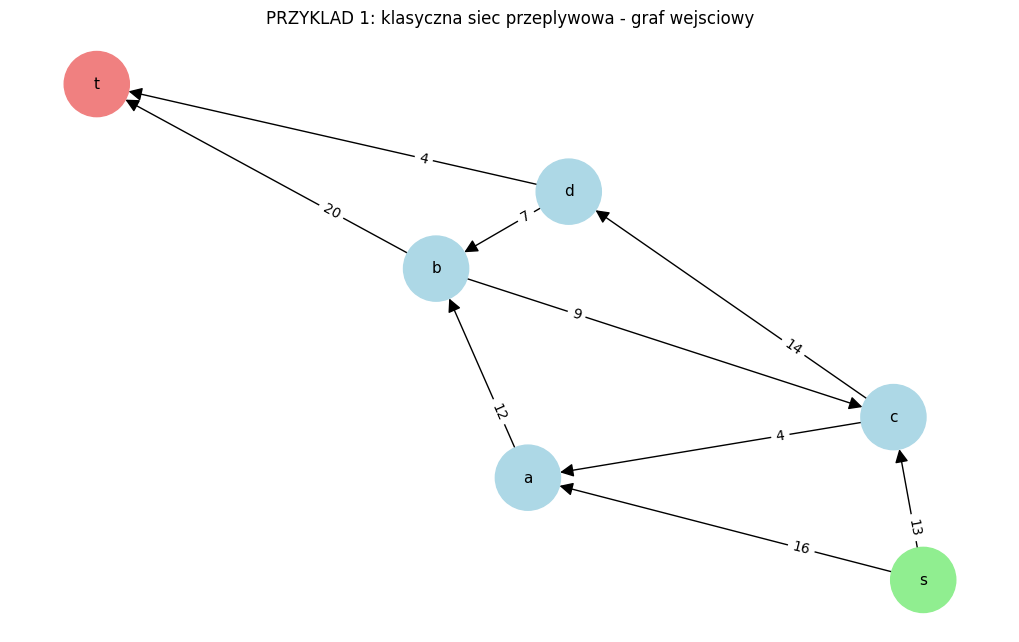

/tmp/ipykernel_7835/334603622.py:690: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


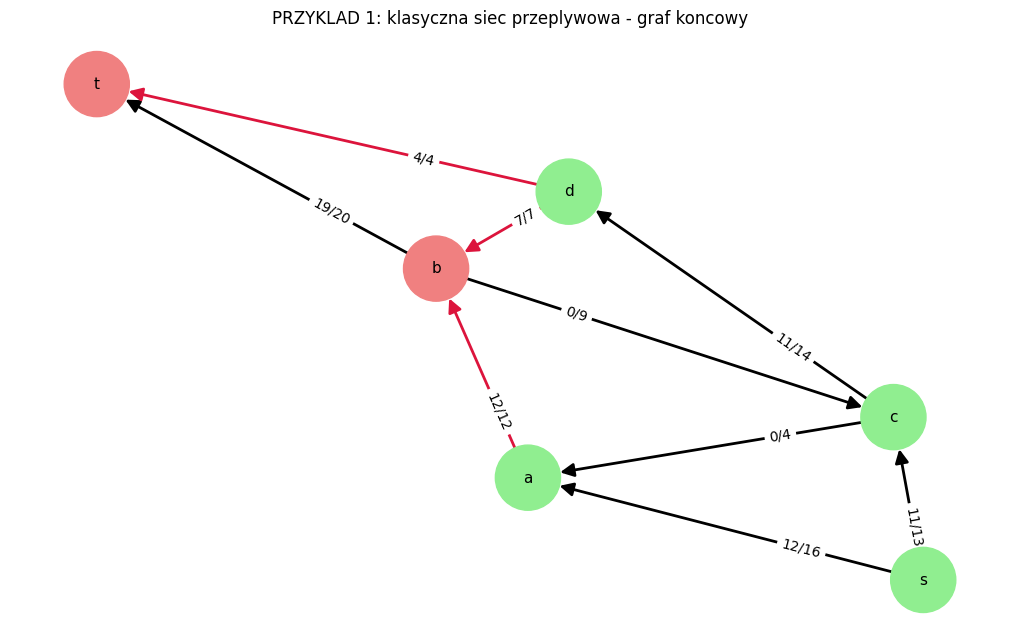

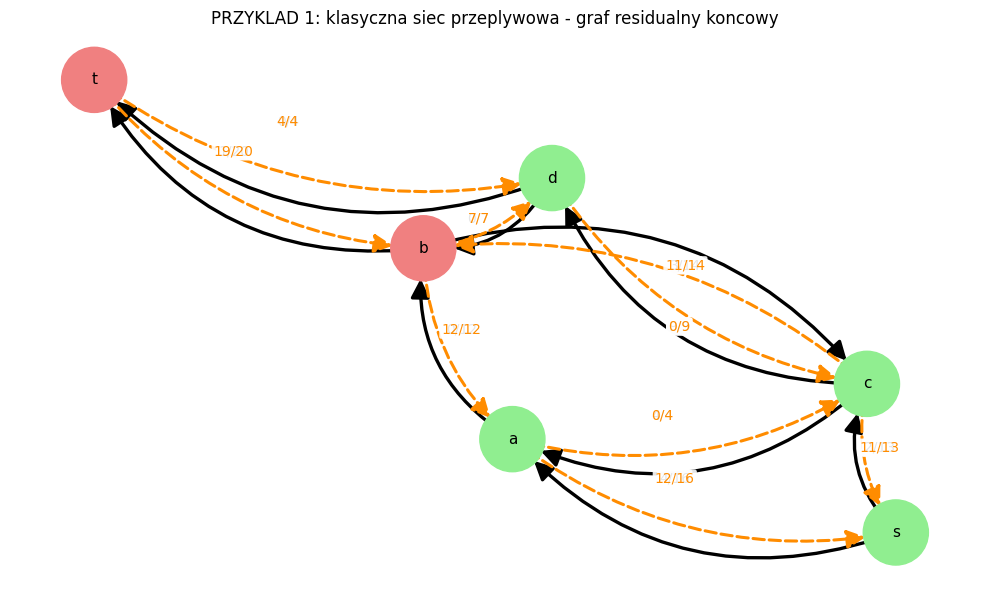

In [ ]:
przyklad_1()